
=== Summary of the dataset ===
Total number of rows : 29910
Columns used :
  - type of energy : primary_fuel
  - capacity       : capacity_mw
  - country/region    : country

=== Missing values ===
primary_fuel: 0
capacity_mw: 0
country: 0

=== Distribution of the types of energy ===
primary_fuel
Hydro             7155
Solar             5929
Wind              5188
Gas               3922
Coal              2390
Oil               2290
Biomass           1396
Waste             1087
Nuclear            198
Geothermal         189
Storage             58
Other               44
Cogeneration        41
Petcoke             13
Wave and Tidal      10

Dominant type of energy : Hydro (7155 power plants, 23.92%)

=== Statistics of Capacities (MW) ===
count    29910.000000
mean       186.294810
std        525.703572
min          1.000000
25%          4.774430
50%         18.900000
75%        100.000000
max      22500.000000

=== Top 10 countries/regions by number of power plants ===
country
USA    8686


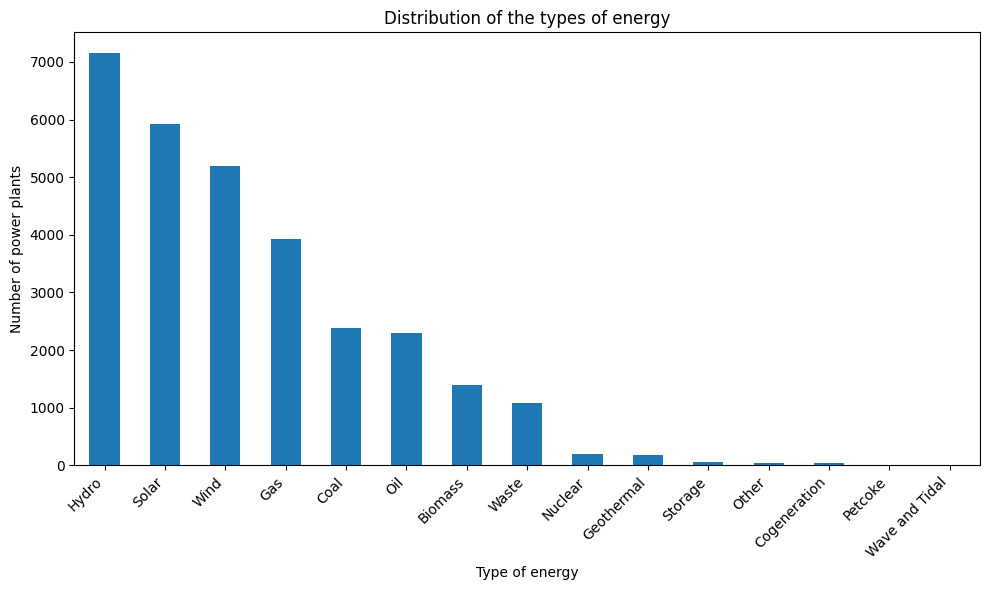

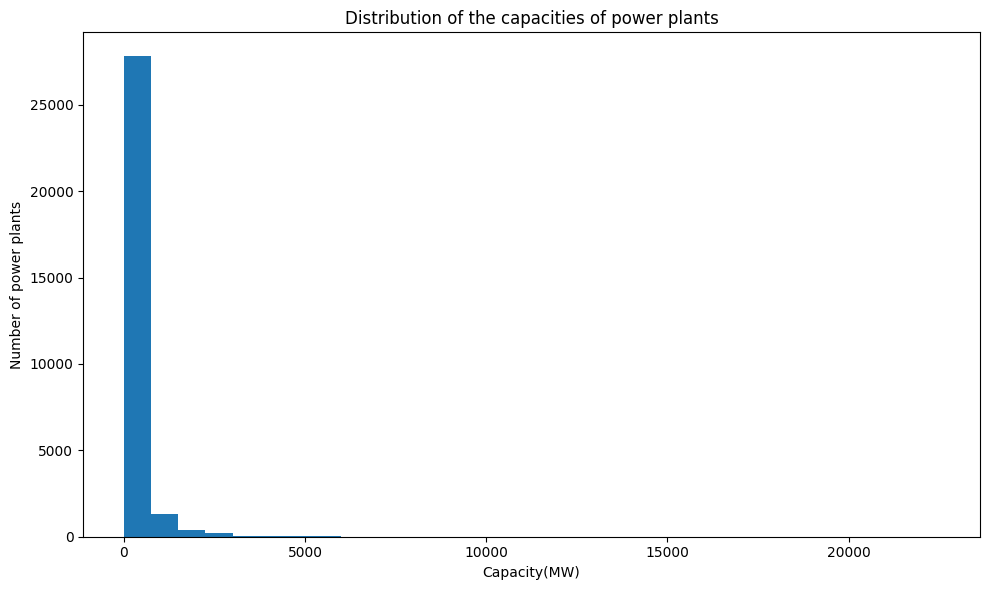

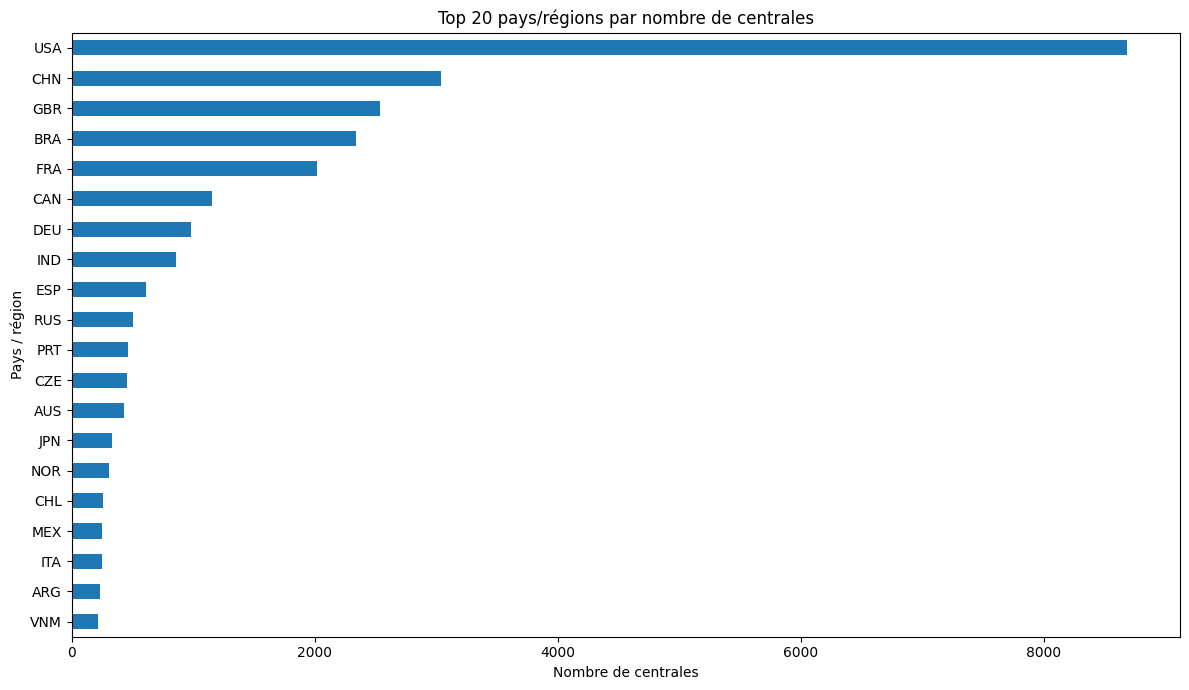

In [1]:
#!/usr/bin/env python3
"""
EDA simple pour un dataset de power plants.

Fonctionnalités :
- distribution des types d'énergie
- histogramme des capacités (MW)
- nombre de centrales par pays/région
- petit résumé texte dans le terminal

Usage :
    python eda_power_plants.py data.csv

Ou avec colonnes explicites :
    python eda_power_plants.py data.csv --fuel-col primary_fuel --capacity-col capacity_mw --country-col country_long

Sauvegarder les figures :
    python eda_power_plants.py data.csv --output-dir results
"""

from __future__ import annotations

import argparse
import os
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd


def normalize_column_name(name: str) -> str:
    return name.strip().lower().replace(" ", "_")


def find_column(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    normalized = {normalize_column_name(col): col for col in df.columns}
    for candidate in candidates:
        if candidate in normalized:
            return normalized[candidate]
    return None


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Exploration univariée d'un dataset de power plants."
    )
    parser.add_argument(
        "csv_file",
        type=str,
        help="Chemin vers le fichier CSV."
    )
    parser.add_argument(
        "--fuel-col",
        type=str,
        default=None,
        help="Nom de la colonne du type d'énergie."
    )
    parser.add_argument(
        "--capacity-col",
        type=str,
        default=None,
        help="Nom de la colonne de capacité en MW."
    )
    parser.add_argument(
        "--country-col",
        type=str,
        default=None,
        help="Nom de la colonne pays/région."
    )
    parser.add_argument(
        "--top-n-countries",
        type=int,
        default=20,
        help="Nombre de pays/régions à afficher dans le bar chart."
    )
    parser.add_argument(
        "--bins",
        type=int,
        default=30,
        help="Nombre de bins pour l'histogramme des capacités."
    )
    parser.add_argument(
        "--output-dir",
        type=str,
        default=None,
        help="Dossier où sauvegarder les graphiques. Si absent, affiche seulement les figures."
    )
    return parser.parse_args()


def validate_file(path: str) -> Path:
    file_path = Path(path)
    if not file_path.exists():
        print(f"Erreur : fichier introuvable : {file_path}", file=sys.stderr)
        sys.exit(1)
    if not file_path.is_file():
        print(f"Erreur : ce chemin n'est pas un fichier : {file_path}", file=sys.stderr)
        sys.exit(1)
    return file_path


def infer_columns(df: pd.DataFrame, args: argparse.Namespace) -> tuple[str, str, str]:
    fuel_col = args.fuel_col or find_column(
        df,
        [
            "primary_fuel",
            "fuel_type",
            "fuel",
            "energy_type",
            "source",
            "generation_type",
        ],
    )

    capacity_col = args.capacity_col or find_column(
        df,
        [
            "capacity_mw",
            "capacity",
            "installed_capacity_mw",
            "net_capacity_mw",
            "mw",
        ],
    )

    country_col = args.country_col or find_column(
        df,
        [
            "country",
            "country_long",
            "country_name",
            "region",
            "area",
        ],
    )

    missing = []
    if fuel_col is None:
        missing.append("type d'énergie")
    if capacity_col is None:
        missing.append("capacité")
    if country_col is None:
        missing.append("pays/région")

    if missing:
        print("Impossible de détecter automatiquement :", ", ".join(missing), file=sys.stderr)
        print("Colonnes disponibles :", list(df.columns), file=sys.stderr)
        print(
            "Utilise --fuel-col, --capacity-col et/ou --country-col pour les préciser.",
            file=sys.stderr,
        )
        sys.exit(1)

    return fuel_col, capacity_col, country_col


def clean_dataframe(
    df: pd.DataFrame,
    fuel_col: str,
    capacity_col: str,
    country_col: str
) -> pd.DataFrame:
    cleaned = df.copy()

    cleaned[fuel_col] = cleaned[fuel_col].astype(str).str.strip()
    cleaned[country_col] = cleaned[country_col].astype(str).str.strip()

    cleaned.loc[cleaned[fuel_col].isin(["", "nan", "None"]), fuel_col] = pd.NA
    cleaned.loc[cleaned[country_col].isin(["", "nan", "None"]), country_col] = pd.NA

    cleaned[capacity_col] = pd.to_numeric(cleaned[capacity_col], errors="coerce")
    cleaned.loc[cleaned[capacity_col] < 0, capacity_col] = pd.NA

    return cleaned


def print_summary(
    df: pd.DataFrame,
    fuel_col: str,
    capacity_col: str,
    country_col: str
) -> None:
    print("\n=== Summary of the dataset ===")
    print(f"Total number of rows : {len(df)}")
    print(f"Columns used :")
    print(f"  - type of energy : {fuel_col}")
    print(f"  - capacity       : {capacity_col}")
    print(f"  - country/region    : {country_col}")

    print("\n=== Missing values ===")
    print(f"{fuel_col}: {df[fuel_col].isna().sum()}")
    print(f"{capacity_col}: {df[capacity_col].isna().sum()}")
    print(f"{country_col}: {df[country_col].isna().sum()}")

    print("\n=== Distribution of the types of energy ===")
    fuel_counts = df[fuel_col].dropna().value_counts()
    print(fuel_counts.to_string())

    if not fuel_counts.empty:
        dominant = fuel_counts.idxmax()
        dominant_count = fuel_counts.iloc[0]
        dominant_pct = 100 * dominant_count / fuel_counts.sum()
        print(
            f"\nDominant type of energy : {dominant} "
            f"({dominant_count} power plants, {dominant_pct:.2f}%)"
        )

    capacities = df[capacity_col].dropna()
    if not capacities.empty:
        print("\n=== Statistics of Capacities (MW) ===")
        print(capacities.describe().to_string())

    country_counts = df[country_col].dropna().value_counts().head(10)
    print("\n=== Top 10 countries/regions by number of power plants ===")
    print(country_counts.to_string())


def plot_fuel_distribution(
    df: pd.DataFrame,
    fuel_col: str,
    output_dir: Optional[Path]
) -> None:
    counts = df[fuel_col].dropna().value_counts()

    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title("Distribution of the types of energy")
    plt.xlabel("Type of energy")
    plt.ylabel("Number of power plants")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "fuel_distribution.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


def plot_capacity_histogram(
    df: pd.DataFrame,
    capacity_col: str,
    bins: int,
    output_dir: Optional[Path]
) -> None:
    capacities = df[capacity_col].dropna()

    plt.figure(figsize=(10, 6))
    plt.hist(capacities, bins=bins)
    plt.title("Distribution of the capacities of power plants")
    plt.xlabel("Capacity(MW)")
    plt.ylabel("Number of power plants")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "capacity_histogram.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


def plot_country_counts(
    df: pd.DataFrame,
    country_col: str,
    top_n: int,
    output_dir: Optional[Path]
) -> None:
    counts = df[country_col].dropna().value_counts().head(top_n)

    plt.figure(figsize=(12, 7))
    counts.sort_values().plot(kind="barh")
    plt.title(f"Top {top_n} pays/régions par nombre de centrales")
    plt.xlabel("Nombre de centrales")
    plt.ylabel("Pays / région")
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "country_counts.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()


df = pd.read_csv("4-power-plants.csv")

args = argparse.Namespace(
    fuel_col=None,
    capacity_col=None,
    country_col=None
)

fuel_col, capacity_col, country_col = infer_columns(df, args)

df = clean_dataframe(df, fuel_col, capacity_col, country_col)

print_summary(df, fuel_col, capacity_col, country_col)

plot_fuel_distribution(df, fuel_col, None)
plot_capacity_histogram(df, capacity_col, 30, None)
plot_country_counts(df, country_col, 20, None)

In [38]:
def plot_fuel_distribution_by_country(
    df: pd.DataFrame,
    fuel_col: str,
    country_col: str,
    top_n_countries: int,
    output_dir: Optional[Path]
) -> None:
    top_countries = df[country_col].dropna().value_counts().head(top_n_countries).index
    filtered = df[df[country_col].isin(top_countries)].dropna(subset=[fuel_col, country_col])

    crosstab = pd.crosstab(filtered[country_col], filtered[fuel_col])
    proportions = crosstab.div(crosstab.sum(axis=1), axis=0)

    plt.figure(figsize=(14, 8))
    proportions.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.xlabel(" ")
    plt.xticks(rotation=45, ha="right", fontsize=15)
    plt.yticks(fontsize=20)
    plt.legend(
    title=" ",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=17,
    
)
    plt.tight_layout()

    if output_dir:
        plt.savefig(output_dir / "fuel_distribution_by_country.png", dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()

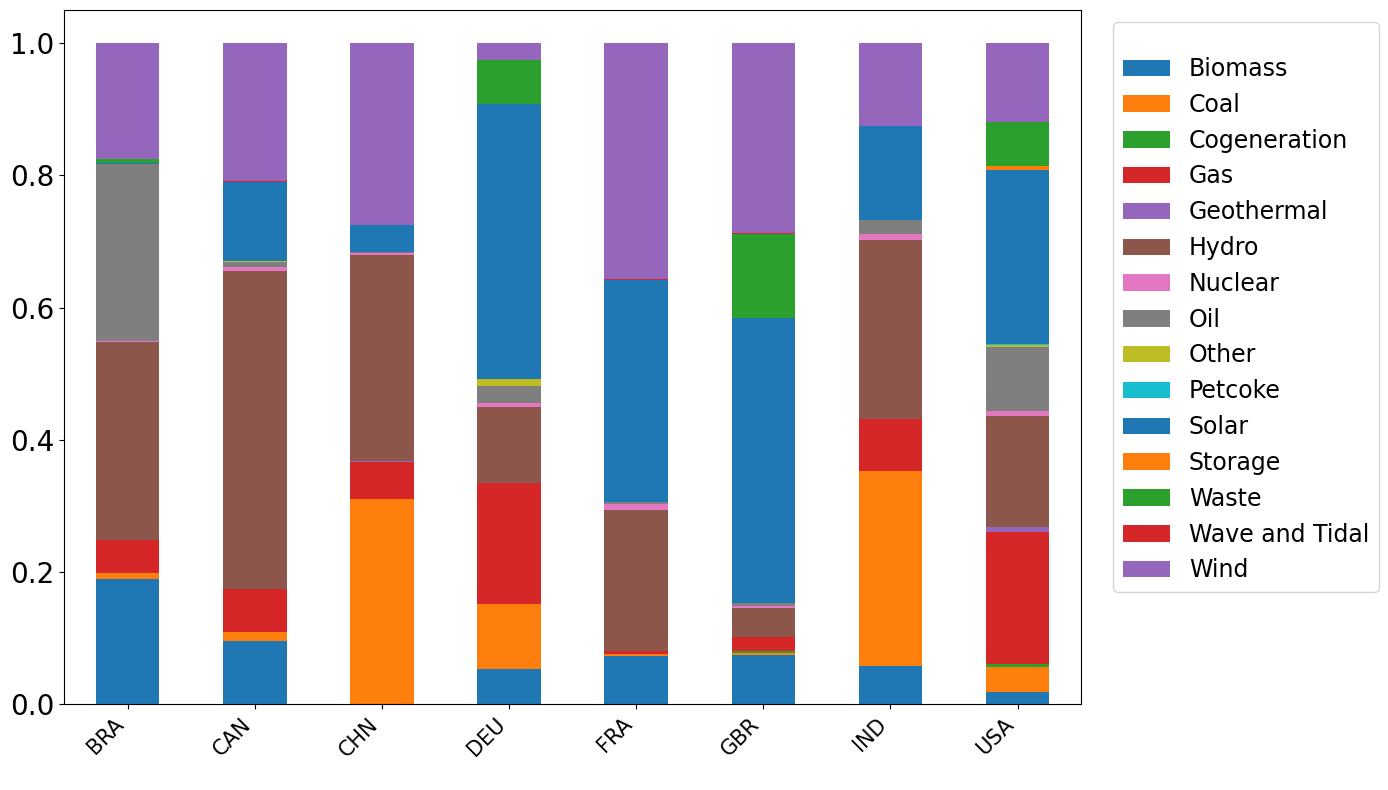

In [39]:
plot_fuel_distribution_by_country(df, fuel_col, country_col, 8, None)

Shape: (29910, 24)

=== BASIC STATISTICS ===
        capacity_mw      latitude     longitude  commissioning_year  \
count  29910.000000  29910.000000  29910.000000        16303.000000   
mean     186.294810     32.497558    -12.458680         1995.486227   
std      525.703572     23.654472     76.978265           23.525537   
min        1.000000    -77.847000   -179.977700         1896.000000   
25%        4.774430     28.863475    -79.211275         1986.000000   
50%       18.900000     40.071250     -3.746700         2005.000000   
75%      100.000000     47.134575     24.931050         2012.063866   
max    22500.000000     71.292000    179.388700         2018.000000   

       year_of_capacity_data  generation_gwh_2013  generation_gwh_2014  \
count           13743.000000          6996.000000          7440.000000   
mean             2016.860001           689.625437           664.840134   
std                 1.195205          2330.869715          2258.351290   
min              20

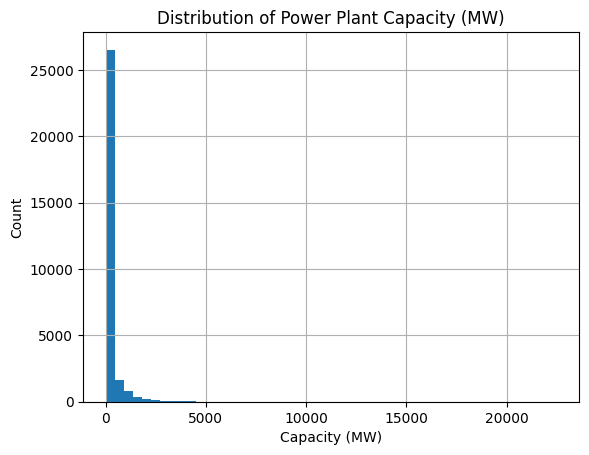


=== POWER PLANTS BY FUEL TYPE ===
primary_fuel
Hydro             7155
Solar             5929
Wind              5188
Gas               3922
Coal              2390
Oil               2290
Biomass           1396
Waste             1087
Nuclear            198
Geothermal         189
Storage             58
Other               44
Cogeneration        41
Petcoke             13
Wave and Tidal      10
Name: count, dtype: int64


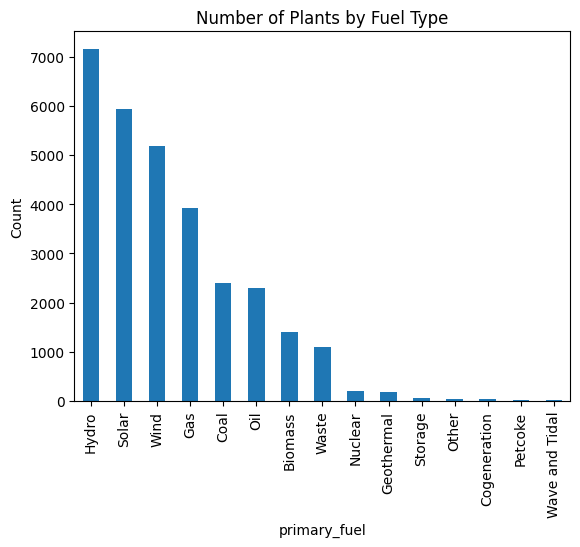


=== CAPACITY BY COUNTRY ===
country_long
China                       1.363283e+06
United States of America    1.193616e+06
India                       2.886941e+05
Russia                      2.275555e+05
Japan                       2.116678e+05
Brazil                      1.457885e+05
Canada                      1.434552e+05
France                      1.092853e+05
Germany                     1.091628e+05
South Korea                 9.940678e+04
Name: capacity_mw, dtype: float64


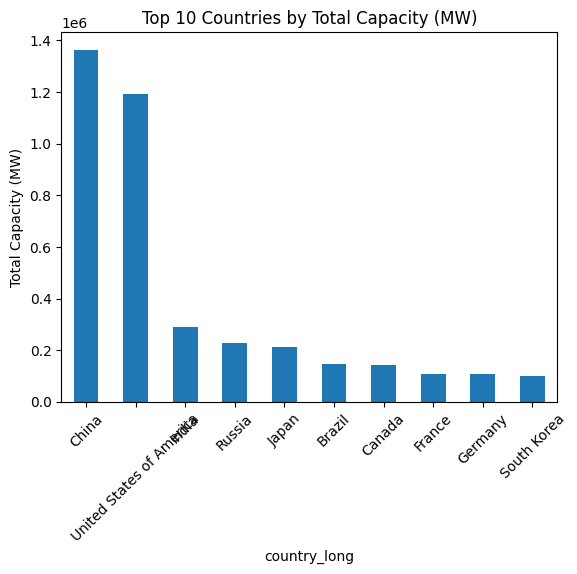


=== COMMISSIONING YEAR ===
Average commissioning year: 1995.4862267343779


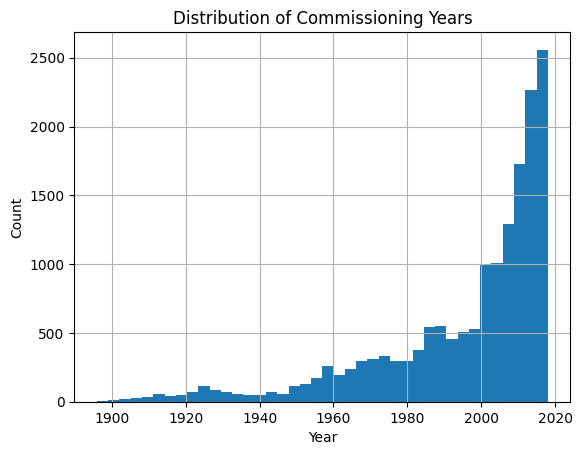


=== GENERATION STATISTICS ===
generation_gwh_2013 mean: 689.6254367873953
generation_gwh_2014 mean: 664.8401336540516
generation_gwh_2015 mean: 664.2707837366355
generation_gwh_2016 mean: 583.6228765522852
generation_gwh_2017 mean: 579.5247229179832

Mean total generation: 861.1064363321916

=== MISSING VALUES ===
other_fuel3              29806
other_fuel2              29607
other_fuel1              27947
generation_gwh_2013      22914
generation_gwh_2014      22470
generation_gwh_2015      21766
generation_gwh_2016      20939
generation_gwh_2017      20697
year_of_capacity_data    16167
commissioning_year       13607
dtype: int64

=== CORRELATIONS ===
capacity_mw                 1.000000
generation_gwh_2017         0.870409
generation_gwh_2013         0.837461
generation_gwh_2016         0.832020
generation_gwh_2014         0.829653
generation_gwh_2015         0.813812
estimated_generation_gwh    0.612863
longitude                   0.186520
commissioning_year          0.007155
latit

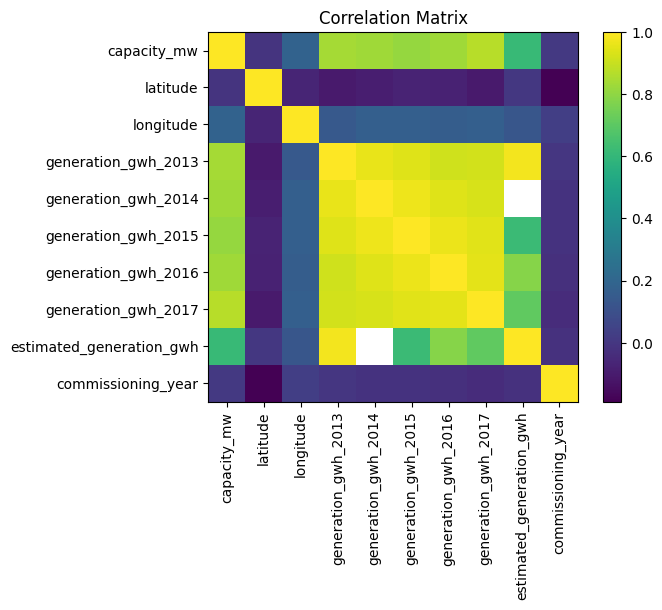


=== AVG CAPACITY BY FUEL ===
primary_fuel
Nuclear           2069.832626
Coal               836.619247
Gas                375.495683
Petcoke            192.082885
Hydro              146.804321
Oil                114.565943
Cogeneration        97.624390
Other               85.399091
Geothermal          66.473810
Wave and Tidal      55.220000
Wind                46.299842
Biomass             24.667408
Waste               13.898081
Solar               10.747651
Storage              7.820690
Name: capacity_mw, dtype: float64


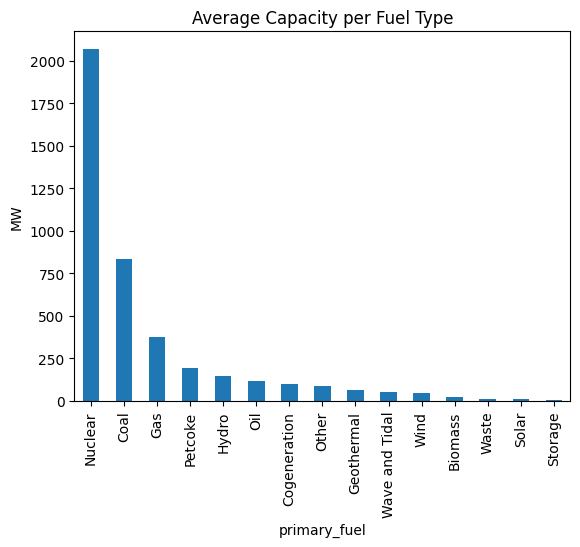

In [42]:
# ===============================
# 1. Imports
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: nicer plots
plt.style.use('default')


# ===============================
# 2. Load Data
# ===============================
# Replace with your file path
df = pd.read_csv("4-power-plants.csv")

# Quick look
print("Shape:", df.shape)
df.head()


# ===============================
# 3. Data Cleaning
# ===============================
# Convert numeric columns safely
numeric_cols = [
    "capacity_mw", "latitude", "longitude",
    "generation_gwh_2013", "generation_gwh_2014",
    "generation_gwh_2015", "generation_gwh_2016",
    "generation_gwh_2017", "estimated_generation_gwh",
    "commissioning_year"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


# ===============================
# 4. General Summary Statistics
# ===============================
print("\n=== BASIC STATISTICS ===")
print(df.describe())


# ===============================
# 5. Capacity Analysis
# ===============================
print("\n=== CAPACITY STATISTICS ===")
print("Mean capacity (MW):", df["capacity_mw"].mean())
print("Median capacity (MW):", df["capacity_mw"].median())
print("Max capacity (MW):", df["capacity_mw"].max())

# Distribution plot
plt.figure()
df["capacity_mw"].hist(bins=50)
plt.title("Distribution of Power Plant Capacity (MW)")
plt.xlabel("Capacity (MW)")
plt.ylabel("Count")
plt.show()


# ===============================
# 6. Counts by Category
# ===============================
print("\n=== POWER PLANTS BY FUEL TYPE ===")
fuel_counts = df["primary_fuel"].value_counts()
print(fuel_counts)

# Plot
plt.figure()
fuel_counts.plot(kind='bar')
plt.title("Number of Plants by Fuel Type")
plt.ylabel("Count")
plt.show()


# ===============================
# 7. Country-Level Aggregations
# ===============================
print("\n=== CAPACITY BY COUNTRY ===")
country_capacity = df.groupby("country_long")["capacity_mw"].sum().sort_values(ascending=False)
print(country_capacity.head(10))

# Plot top 10
plt.figure()
country_capacity.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Total Capacity (MW)")
plt.ylabel("Total Capacity (MW)")
plt.xticks(rotation=45)
plt.show()


# ===============================
# 8. Commissioning Year Analysis
# ===============================
print("\n=== COMMISSIONING YEAR ===")
print("Average commissioning year:", df["commissioning_year"].mean())

plt.figure()
df["commissioning_year"].dropna().hist(bins=40)
plt.title("Distribution of Commissioning Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


# ===============================
# 9. Generation Analysis
# ===============================
generation_cols = [
    "generation_gwh_2013",
    "generation_gwh_2014",
    "generation_gwh_2015",
    "generation_gwh_2016",
    "generation_gwh_2017"
]

print("\n=== GENERATION STATISTICS ===")
for col in generation_cols:
    if col in df.columns:
        print(f"{col} mean:", df[col].mean())

# Total generation per plant (row-wise)
df["total_generation"] = df[generation_cols].sum(axis=1, skipna=True)

print("\nMean total generation:", df["total_generation"].mean())


# ===============================
# 10. Missing Data Overview
# ===============================
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(10))


# ===============================
# 11. Correlation Analysis
# ===============================
print("\n=== CORRELATIONS ===")
corr = df[numeric_cols].corr()
print(corr["capacity_mw"].sort_values(ascending=False))

# Heatmap (simple)
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()


# ===============================
# 12. Bonus: Fuel vs Capacity
# ===============================
fuel_capacity = df.groupby("primary_fuel")["capacity_mw"].mean().sort_values(ascending=False)

print("\n=== AVG CAPACITY BY FUEL ===")
print(fuel_capacity)

plt.figure()
fuel_capacity.plot(kind='bar')
plt.title("Average Capacity per Fuel Type")
plt.ylabel("MW")
plt.show()